# Generating an Irregular Series

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [95]:
np.random.seed(42)

In [96]:
# Simulate customer transaction timestamps
# Gaps between transactions follow an exponential distribution
# (standard model for random arrival times)

n_events = 200      # 200 transaction records
gaps = np.random.exponential(scale=4, size=n_events)    # avg_gap = 4 hours
gaps

array([ 1.87707236, 12.04048572,  5.26698277,  3.65177022,  0.67849948,
        0.67838517,  0.23935507,  8.04492346,  3.67632861,  4.92500025,
        0.08319723, 14.0142299 ,  7.14571817,  0.9547505 ,  0.80271595,
        0.81044569,  1.45101492,  2.97571132,  2.26214827,  1.37689197,
        3.7854835 ,  0.60093811,  1.38206205,  1.82510887,  2.43573875,
        6.15174404,  0.89094345,  2.88811662,  3.59001889,  0.1902554 ,
        3.74133208,  0.74784501,  0.26905572, 11.89475117, 13.48252137,
        6.60932629,  1.45315144,  0.41110926,  4.61100305,  2.32036337,
        0.52060894,  2.73418891,  0.13997489,  9.60169155,  1.19783111,
        4.34502319,  1.49418633,  2.93644358,  3.16489519,  0.8175544 ,
       13.97122853,  5.96898151, 11.22037768,  9.00860799,  3.64421765,
       10.19774152,  0.37062184,  0.87253878,  0.18512786,  1.57412835,
        1.96852117,  1.26624177,  7.05823146,  1.764908  ,  1.31921136,
        3.12962833,  0.60759259,  6.48193438,  0.30990348, 17.33

In [97]:
print(np.cumsum(gaps))

[  1.87707236  13.91755808  19.18454086  22.83631107  23.51481055
  24.19319572  24.4325508   32.47747425  36.15380287  41.07880312
  41.16200035  55.17623025  62.32194842  63.27669892  64.07941488
  64.88986057  66.34087549  69.31658681  71.57873508  72.95562705
  76.74111054  77.34204866  78.72411071  80.54921958  82.98495833
  89.13670238  90.02764582  92.91576244  96.50578133  96.69603673
 100.43736881 101.18521382 101.45426954 113.34902072 126.83154209
 133.44086838 134.89401982 135.30512908 139.91613213 142.2364955
 142.75710444 145.49129335 145.63126823 155.23295978 156.43079089
 160.77581409 162.27000041 165.206444   168.37133919 169.18889359
 183.16012212 189.12910362 200.3494813  209.35808929 213.00230694
 223.20004846 223.57067029 224.44320907 224.62833694 226.20246528
 228.17098645 229.43722822 236.49545968 238.26036768 239.57957904
 242.70920738 243.31679997 249.79873435 250.10863783 267.44522318
 273.36315829 274.24931605 274.27146573 281.03105284 285.93943647
 291.162088

In [98]:
print(np.mean(gaps))

3.7819459091349974


In [99]:
# cumsum - Cumulative sum of the gaps. This is the hours elapsed since the start for each event
# pd.to_timedelta converts those elapsed hours into actual time duration that pandas understands
# pd.to_datetime --> Adds each duration to the start date, giving the real timestamps
timestamps = pd.to_datetime("2022-01-01") + pd.to_timedelta(np.cumsum(gaps), unit="h")
timestamps

DatetimeIndex(['2022-01-01 01:52:37.460495665',
               '2022-01-01 13:55:03.209100880',
               '2022-01-01 19:11:04.347087932',
               '2022-01-01 22:50:10.719862306',
               '2022-01-01 23:30:53.317996966',
               '2022-01-02 00:11:35.504600535',
               '2022-01-02 00:25:57.182868501',
               '2022-01-02 08:28:38.907317010',
               '2022-01-02 12:09:13.690329242',
               '2022-01-02 17:04:43.691217790',
               ...
               '2022-01-30 05:37:24.329548405',
               '2022-01-30 14:43:26.103991206',
               '2022-01-30 23:57:03.655749344',
               '2022-01-31 03:57:42.102589896',
               '2022-01-31 05:37:04.372331178',
               '2022-01-31 07:20:10.145998867',
               '2022-01-31 12:30:50.448186935',
               '2022-01-31 21:36:37.450014080',
               '2022-02-01 06:20:05.759013393',
               '2022-02-01 12:23:21.054577200'],
              dtype=

In [100]:
# Generates the transaction amounts --> Avg transaction is 150 dollars and the + 20 is for that no transaction is below 20 dollars
transaction_values = np.random.exponential(scale=150, size=n_events) + 20

In [101]:
transaction_values

array([174.09660404,  33.18375893,  46.4441322 , 363.23457503,
       159.87409204,  21.38594084,  36.04953522, 183.37435809,
        20.76116556,  46.29737242, 139.35467692, 196.597293  ,
       178.31622232,  58.0924801 , 206.81259333,  60.62356386,
        79.04523634, 225.85363275, 177.31607215, 303.79341162,
       180.77199323, 146.00664584,  34.75355922,  88.76244608,
        66.22402218,  61.95503055, 561.84641092,  94.90812456,
       353.90828169, 169.60015786, 257.5737879 , 124.76529866,
       149.0233854 , 121.744015  ,  52.5822343 , 212.26427046,
        69.43660525,  23.69247216, 175.54531794,  49.24003553,
       443.16247209, 481.63436192, 389.5264827 ,  89.34310947,
        22.33659731, 415.3285186 , 103.84074156, 530.12630242,
       517.06032142, 307.60805258,  72.31641023,  92.94378981,
       305.70899787,  77.17193471,  47.85779244, 142.06054881,
       432.69402062, 198.62383966, 146.61685047,  35.3342296 ,
       163.17960733, 711.58546218,  42.638088  , 129.57

In [102]:
df = pd.DataFrame({'timestamp': timestamps, 'amount': transaction_values.round(2)})
df.set_index('timestamp', inplace=True)

In [103]:
df.head()

,amount
timestamp,
2022-01-01 01:52:37.460495665,174.10
2022-01-01 13:55:03.209100880,33.18
2022-01-01 19:11:04.347087932,46.44
2022-01-01 22:50:10.719862306,363.23
2022-01-01 23:30:53.317996966,159.87


In [104]:
print(f"Total records  : {len(df)}")
print(f"Date range     : {df.index.min()} → {df.index.max()}")
print(f"Detected freq  : {df.index.freq}")     # None — confirms irregular

Total records  : 200
Date range     : 2022-01-01 01:52:37.460495665 → 2022-02-01 12:23:21.054577200
Detected freq  : None


# Visualizing the irregularity

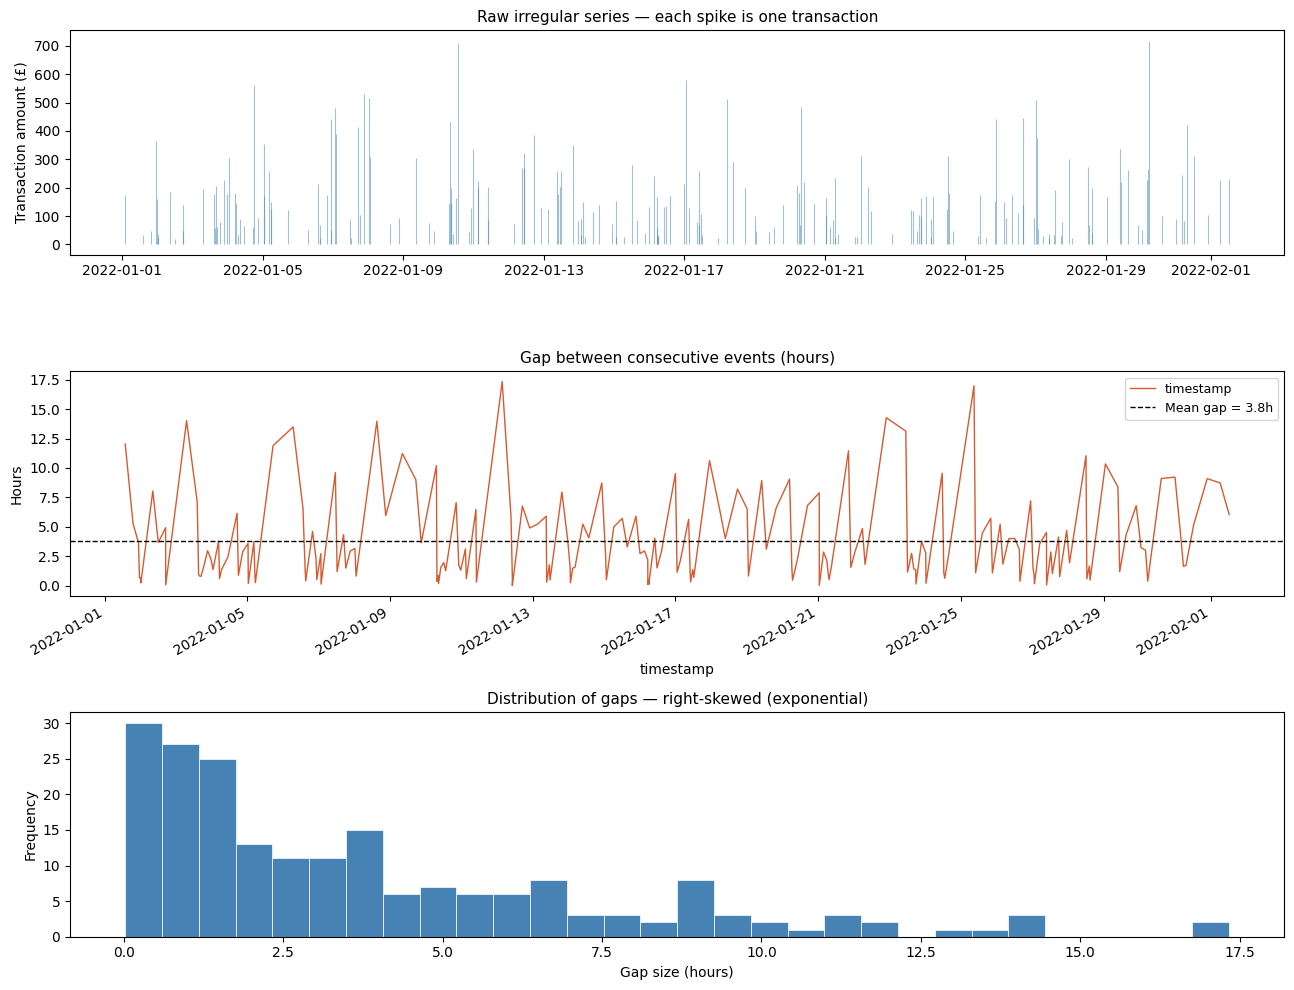

In [105]:
# Compute gaps between consecutive timestamps

# df.index.to_series() converts the DatetimeIndex into a regular pandas Series so we can do arithmetic on it
gaps_actual = df.index.to_series().diff().dt.total_seconds() / 3600  # in hours

fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# Panel 1 — raw irregular series as an event plot
axes[0].vlines(df.index, ymin=0, ymax=df['amount'],
               color='steelblue', alpha=0.5, linewidth=0.8)
axes[0].set_title('Raw irregular series — each spike is one transaction', fontsize=11)
axes[0].set_ylabel('Transaction amount (£)')

# Panel 2 — gaps between events
gaps_actual.plot(ax=axes[1], color='#D85A30', linewidth=1.0)
axes[1].axhline(gaps_actual.mean(), color='black', linestyle='--',
                linewidth=1, label=f'Mean gap = {gaps_actual.mean():.1f}h')
axes[1].set_title('Gap between consecutive events (hours)', fontsize=11)
axes[1].set_ylabel('Hours')
axes[1].legend(fontsize=9)

# Panel 3 — distribution of gaps
gaps_actual.dropna().plot(kind='hist', ax=axes[2], bins=30,
                          color='steelblue', edgecolor='white', linewidth=0.5)
axes[2].set_title('Distribution of gaps — right-skewed (exponential)', fontsize=11)
axes[2].set_xlabel('Gap size (hours)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('irregular_series.png', dpi=150, bbox_inches='tight')
plt.show()

Panel 1 shows the raw event series — spikes of varying heights with unequal horizontal spacing. Some spikes cluster together (burst of transactions), others are isolated (quiet periods).

Panel 2 shows the gap size at each step. High variance in this line = highly irregular. A flat line would mean regular.

Panel 3 shows the gap distribution — a right-skewed exponential shape is the signature of a random arrival process. Most gaps are short, occasional gaps are very long. This is completely normal and expected for event-driven data.

# The solution - Resample to a Regular Grid

In [106]:
# Resample to hourly buckets — sum of transactions per hour

# resample('H') --> divides the entire time axis into 1-hour buckets. Every transaction that falls within the same hour gets grouped together.
hourly_sum   = df['amount'].resample('H').sum()


# resample('D') --> Resample to daily buckets
daily_sum    = df['amount'].resample('D').sum()
daily_count  = df['amount'].resample('D').count()   # number of events per day
daily_mean   = df['amount'].resample('D').mean()    # average transaction size

print("Hourly resampled (first 24 rows):")
print(hourly_sum.head(24))
print(f"\nZero hours (no transactions): {(hourly_sum == 0).sum()}")

Hourly resampled (first 24 rows):
timestamp
2022-01-01 01:00:00    174.10
2022-01-01 02:00:00      0.00
2022-01-01 03:00:00      0.00
2022-01-01 04:00:00      0.00
2022-01-01 05:00:00      0.00
2022-01-01 06:00:00      0.00
2022-01-01 07:00:00      0.00
2022-01-01 08:00:00      0.00
2022-01-01 09:00:00      0.00
2022-01-01 10:00:00      0.00
2022-01-01 11:00:00      0.00
2022-01-01 12:00:00      0.00
2022-01-01 13:00:00     33.18
2022-01-01 14:00:00      0.00
2022-01-01 15:00:00      0.00
2022-01-01 16:00:00      0.00
2022-01-01 17:00:00      0.00
2022-01-01 18:00:00      0.00
2022-01-01 19:00:00     46.44
2022-01-01 20:00:00      0.00
2022-01-01 21:00:00      0.00
2022-01-01 22:00:00    363.23
2022-01-01 23:00:00    159.87
2022-01-02 00:00:00     57.44
Freq: h, Name: amount, dtype: float64

Zero hours (no transactions): 582


C:\Users\muham\AppData\Local\Temp\ipykernel_24128\2606290260.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_sum   = df['amount'].resample('H').sum()


# Choosing the right resampling frequency

In [107]:
# This loop tries four different frequencies and measures sparsity at each one.


# ('H','Hourly') — tuple of the pandas frequency string and a human-readable label. The loop unpacks each tuple into freq and label.
# resampled = df['amount'].resample(freq).sum() — resamples at the current frequency.
# empty = (resampled == 0).sum() — counts empty buckets at this frequency.
# pct_empty = 100 * empty / len(resampled) — percentage of buckets that are empty.
for freq, label in [('H','Hourly'), ('4H','4-Hourly'), ('D','Daily'), ('W','Weekly')]:
    resampled = df['amount'].resample(freq).sum()
    empty = (resampled == 0).sum()
    pct_empty = 100 * empty / len(resampled)
    print(f"{label:<10} → {len(resampled):>4} buckets, {empty:>3} empty ({pct_empty:.1f}%)")

Hourly     →  756 buckets, 582 empty (77.0%)
4-Hourly   →  190 buckets,  69 empty (36.3%)
Daily      →   32 buckets,   0 empty (0.0%)
Weekly     →    6 buckets,   0 empty (0.0%)


C:\Users\muham\AppData\Local\Temp\ipykernel_24128\1339989852.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampled = df['amount'].resample(freq).sum()


# Handling empty buckets

In [108]:
daily = df['amount'].resample('D').sum()

daily_kept   = daily.fillna(0)
daily_interp = daily.replace(0, np.nan).interpolate(method='time')
daily_count  = df['amount'].resample('D').count()


# fter resample('D').sum(), days with no transactions are NaN in the result (not zero — pandas uses NaN for empty buckets, not zero).
# daily.fillna(0) — replaces NaN with zero. Correct for transactions — no sales genuinely means £0 revenue.
# daily.replace(0, np.nan) — converts zeros to NaN first. This is needed for the sensor case where zero is suspicious, not meaningful.
# .interpolate(method='time') — fills NaN by drawing a line between surrounding known values, weighted by the actual time gap. Unlike plain method='linear' which assumes equal spacing, method='time' accounts for the fact that some gaps are longer than others.